In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load the Breast Cancer Wisconsin Diagnostic dataset
data = load_breast_cancer()

# Convert features into DataFrame
X = pd.DataFrame(data.data, columns=data.feature_names)

# Target
y = pd.Series(data.target, name="target")

print("Dataset loaded successfully!")
print("Number of rows:", X.shape[0])
print("Number of features:", X.shape[1])

Dataset loaded successfully!
Number of rows: 569
Number of features: 30


In [3]:
print("Target names:")
print(data.target_names)

print("\nTarget values:")
print(np.unique(y, return_counts=True))

Target names:
['malignant' 'benign']

Target values:
(array([0, 1]), array([212, 357]))


In [4]:
# Original:
# 0 = malignant
# 1 = benign

# New:
# 1 = malignant
# 0 = benign

y = 1 - y

print(y.value_counts())

print("\nTarget meaning:")
print("0 = Benign")
print("1 = Malignant")

target
0    357
1    212
Name: count, dtype: int64

Target meaning:
0 = Benign
1 = Malignant


In [5]:
df = X.copy()

df["Disease"] = y

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Disease
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


In [6]:
print("Dataset Shape:")
print(df.shape)

print("\nDataset Information:")
df.info()

Dataset Shape:
(569, 31)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-

In [7]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Disease
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.372583
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,0.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [8]:
print("Missing values in each column:")

missing_values = df.isnull().sum()

print(missing_values)

print("\nTotal missing values:", missing_values.sum())

Missing values in each column:
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
Disease                    0
dtype: int64

Total missing values: 0


In [9]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [10]:
print("Disease distribution:")
print(df["Disease"].value_counts())

print("\nPercentage distribution:")
print(df["Disease"].value_counts(normalize=True) * 100)

Disease distribution:
Disease
0    357
1    212
Name: count, dtype: int64

Percentage distribution:
Disease
0    62.741652
1    37.258348
Name: proportion, dtype: float64


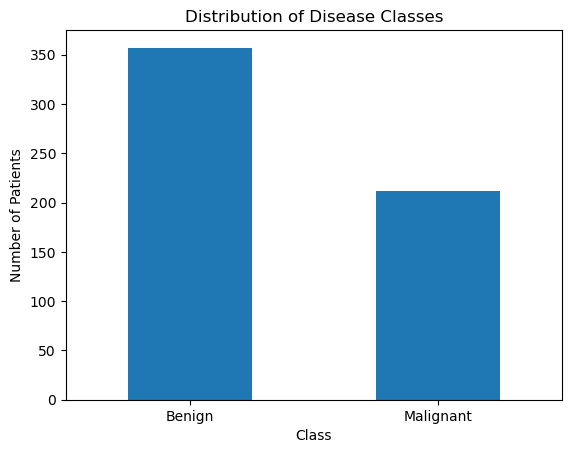

In [11]:
df["Disease"].value_counts().plot(kind="bar")

plt.title("Distribution of Disease Classes")
plt.xlabel("Class")
plt.ylabel("Number of Patients")

plt.xticks(
    ticks=[0, 1],
    labels=["Benign", "Malignant"],
    rotation=0
)

plt.show()

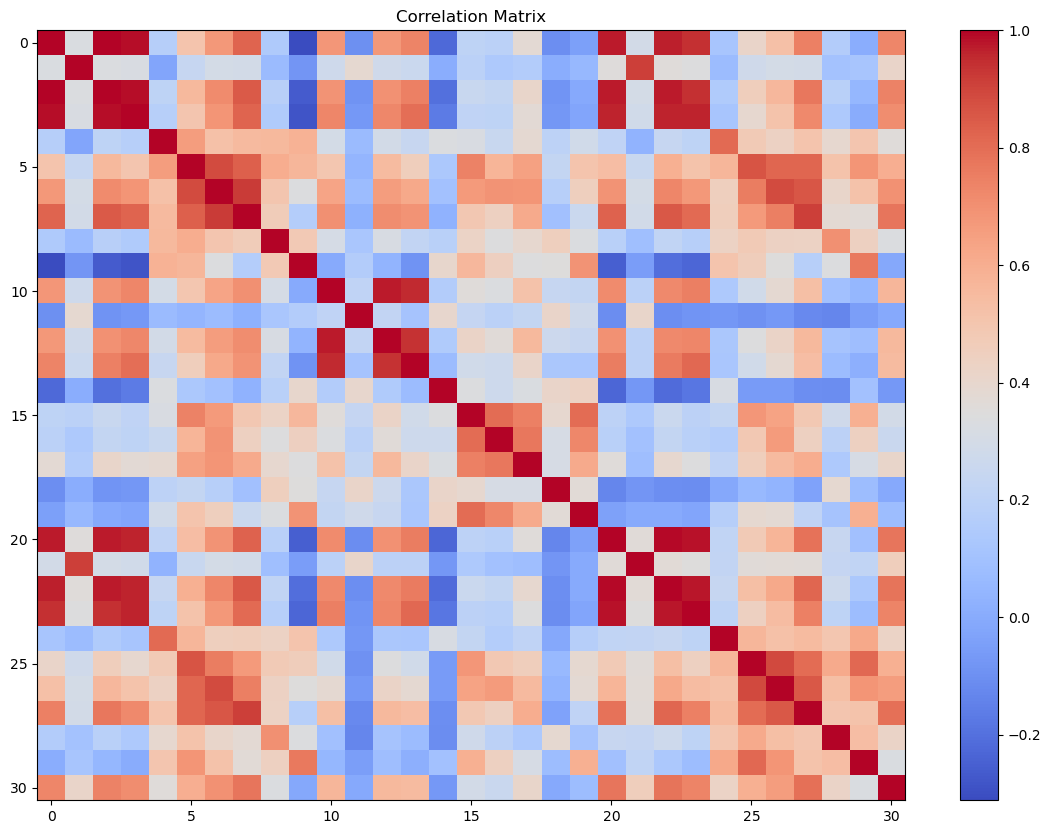

In [12]:
correlation = df.corr(numeric_only=True)

plt.figure(figsize=(14, 10))

plt.imshow(correlation, cmap="coolwarm", aspect="auto")

plt.colorbar()

plt.title("Correlation Matrix")

plt.show()

In [13]:
X = df.drop("Disease", axis=1)

y = df["Disease"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (569, 30)
Target shape: (569,)


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (455, 30)
Testing data: (114, 30)


In [15]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


In [16]:
logistic_model = LogisticRegression(max_iter=5000)

logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [17]:
y_pred_lr = logistic_model.predict(X_test_scaled)

y_prob_lr = logistic_model.predict_proba(X_test_scaled)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


In [18]:
print("Logistic Regression Classification Report:\n")

print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=["Benign", "Malignant"]
    )
)

Logistic Regression Classification Report:

              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [19]:
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)
lr_roc_auc = roc_auc_score(y_test, y_prob_lr)

print("Logistic Regression Results")
print("--------------------------------")

print("Accuracy :", round(lr_accuracy, 4))
print("Precision:", round(lr_precision, 4))
print("Recall   :", round(lr_recall, 4))
print("F1-Score :", round(lr_f1, 4))
print("ROC-AUC  :", round(lr_roc_auc, 4))

Logistic Regression Results
--------------------------------
Accuracy : 0.9649
Precision: 0.975
Recall   : 0.9286
F1-Score : 0.9512
ROC-AUC  : 0.996


In [20]:
svm_model = SVC(
    kernel="rbf",
    probability=True,
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)

print("SVM model trained successfully.")

SVM model trained successfully.


In [21]:
y_pred_svm = svm_model.predict(X_test_scaled)

y_prob_svm = svm_model.predict_proba(X_test_scaled)[:, 1]

print("SVM predictions generated.")

SVM predictions generated.


In [22]:
print("SVM Classification Report:\n")

print(
    classification_report(
        y_test,
        y_pred_svm,
        target_names=["Benign", "Malignant"]
    )
)

SVM Classification Report:

              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



In [23]:
svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_precision = precision_score(y_test, y_pred_svm)
svm_recall = recall_score(y_test, y_pred_svm)
svm_f1 = f1_score(y_test, y_pred_svm)
svm_roc_auc = roc_auc_score(y_test, y_prob_svm)

print("SVM Results")
print("--------------------------------")

print("Accuracy :", round(svm_accuracy, 4))
print("Precision:", round(svm_precision, 4))
print("Recall   :", round(svm_recall, 4))
print("F1-Score :", round(svm_f1, 4))
print("ROC-AUC  :", round(svm_roc_auc, 4))

SVM Results
--------------------------------
Accuracy : 0.9737
Precision: 1.0
Recall   : 0.9286
F1-Score : 0.963
ROC-AUC  : 0.9947


In [24]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [25]:
y_pred_rf = rf_model.predict(X_test)

y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest predictions generated.")

Random Forest predictions generated.


In [26]:
print("Random Forest Classification Report:\n")

print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=["Benign", "Malignant"]
    )
)

Random Forest Classification Report:

              precision    recall  f1-score   support

      Benign       0.95      1.00      0.97        72
   Malignant       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



In [27]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_roc_auc = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Results")
print("--------------------------------")

print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1-Score :", round(rf_f1, 4))
print("ROC-AUC  :", round(rf_roc_auc, 4))

Random Forest Results
--------------------------------
Accuracy : 0.9649
Precision: 1.0
Recall   : 0.9048
F1-Score : 0.95
ROC-AUC  : 0.9942


In [28]:
try:
    from xgboost import XGBClassifier
    print("XGBoost is installed.")

except ImportError:
    print("XGBoost is not installed.")
    print("Run the next cell to install it.")

XGBoost is not installed.
Run the next cell to install it.


In [29]:
!pip install xgboost

   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   - -------------------------------------- 2.1/48.9 MB 14.0 MB/s eta 0:00:04
   ------ --------------------------------- 7.6/48.9 MB 21.0 MB/s eta 0:00:02
   --------- ------------------------------ 12.1/48.9 MB 21.5 MB/s eta 0:00:02
   -------------- ------------------------- 17.8/48.9 MB 22.8 MB/s eta 0:00:02
   ------------------ --------------------- 23.1/48.9 MB 23.2 MB/s eta 0:00:02
   ----------------------- ---------------- 28.6/48.9 MB 23.7 MB/s eta 0:00:01
   --------------------------- ------------ 34.1/48.9 MB 24.2 MB/s eta 0:00:01
   -------------------------------- ------- 39.6/48.9 MB 24.5 MB/s eta 0:00:01
   ------------------------------------- -- 45.4/48.9 MB 24.8 MB/s eta 0:00:01
   ---------------------------------------  48.8/48.9 MB 24.9 MB/s eta 0:00:01
   ---------------------------------------- 48.9/48.9 MB 22.7 MB/s  0:00:02


In [30]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(X_train, y_train)

print("XGBoost model trained successfully.")

XGBoost model trained successfully.


In [31]:
y_pred_xgb = xgb_model.predict(X_test)

y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost predictions generated.")

XGBoost predictions generated.


In [32]:
print("XGBoost Classification Report:\n")

print(
    classification_report(
        y_test,
        y_pred_xgb,
        target_names=["Benign", "Malignant"]
    )
)

XGBoost Classification Report:

              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



In [33]:
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)
xgb_roc_auc = roc_auc_score(y_test, y_prob_xgb)

print("XGBoost Results")
print("--------------------------------")

print("Accuracy :", round(xgb_accuracy, 4))
print("Precision:", round(xgb_precision, 4))
print("Recall   :", round(xgb_recall, 4))
print("F1-Score :", round(xgb_f1, 4))
print("ROC-AUC  :", round(xgb_roc_auc, 4))

XGBoost Results
--------------------------------
Accuracy : 0.9737
Precision: 1.0
Recall   : 0.9286
F1-Score : 0.963
ROC-AUC  : 0.9957


In [34]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "SVM",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy": [
        lr_accuracy,
        svm_accuracy,
        rf_accuracy,
        xgb_accuracy
    ],

    "Precision": [
        lr_precision,
        svm_precision,
        rf_precision,
        xgb_precision
    ],

    "Recall": [
        lr_recall,
        svm_recall,
        rf_recall,
        xgb_recall
    ],

    "F1-Score": [
        lr_f1,
        svm_f1,
        rf_f1,
        xgb_f1
    ],

    "ROC-AUC": [
        lr_roc_auc,
        svm_roc_auc,
        rf_roc_auc,
        xgb_roc_auc
    ]
})

results

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.964912,0.975,0.928571,0.951220,0.996032
1,SVM,0.973684,1.000,0.928571,0.962963,0.994709
2,Random Forest,0.964912,1.000,0.904762,0.950000,0.994213
3,XGBoost,0.973684,1.000,0.928571,0.962963,0.995701


In [35]:
results_rounded = results.copy()

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
]

results_rounded[metric_columns] = results_rounded[metric_columns].round(4)

results_rounded

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.9649,0.975,0.9286,0.9512,0.9960
1,SVM,0.9737,1.000,0.9286,0.9630,0.9947
2,Random Forest,0.9649,1.000,0.9048,0.9500,0.9942
3,XGBoost,0.9737,1.000,0.9286,0.9630,0.9957


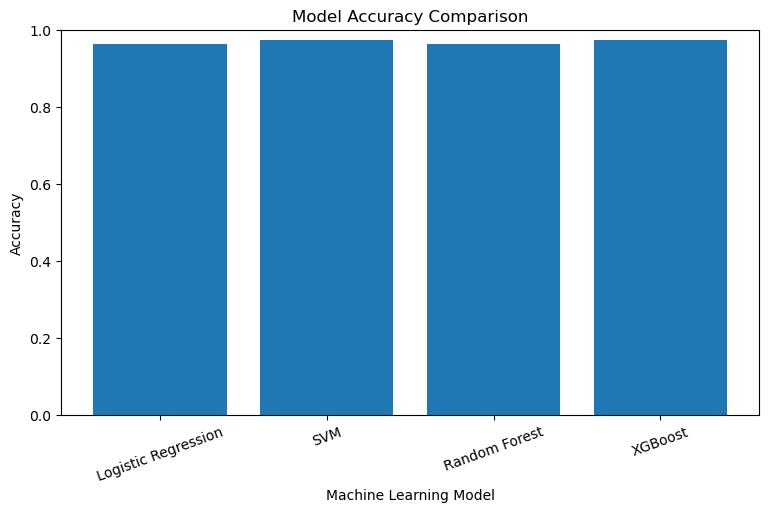

In [36]:
plt.figure(figsize=(9, 5))

plt.bar(
    results["Model"],
    results["Accuracy"]
)

plt.title("Model Accuracy Comparison")

plt.xlabel("Machine Learning Model")

plt.ylabel("Accuracy")

plt.ylim(0, 1)

plt.xticks(rotation=20)

plt.show()

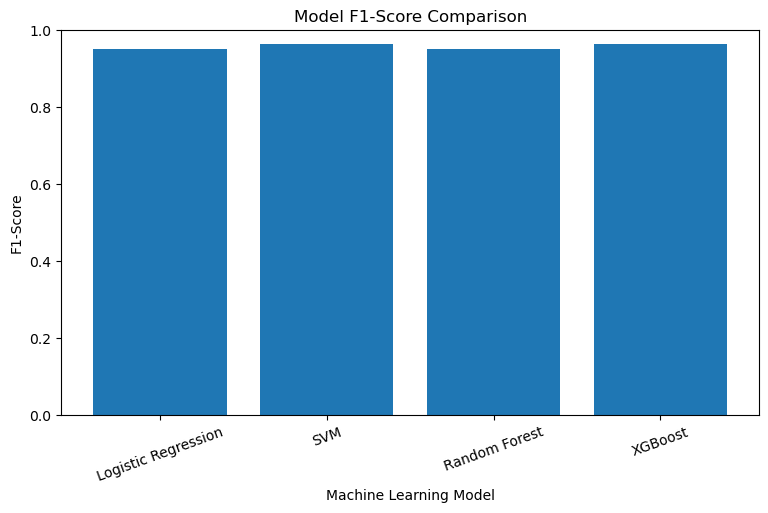

In [37]:
plt.figure(figsize=(9, 5))

plt.bar(
    results["Model"],
    results["F1-Score"]
)

plt.title("Model F1-Score Comparison")

plt.xlabel("Machine Learning Model")

plt.ylabel("F1-Score")

plt.ylim(0, 1)

plt.xticks(rotation=20)

plt.show()

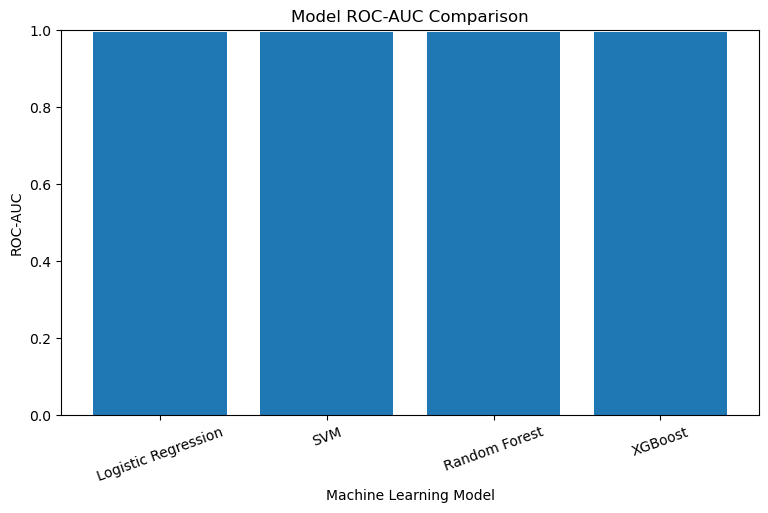

In [38]:
plt.figure(figsize=(9, 5))

plt.bar(
    results["Model"],
    results["ROC-AUC"]
)

plt.title("Model ROC-AUC Comparison")

plt.xlabel("Machine Learning Model")

plt.ylabel("ROC-AUC")

plt.ylim(0, 1)

plt.xticks(rotation=20)

plt.show()

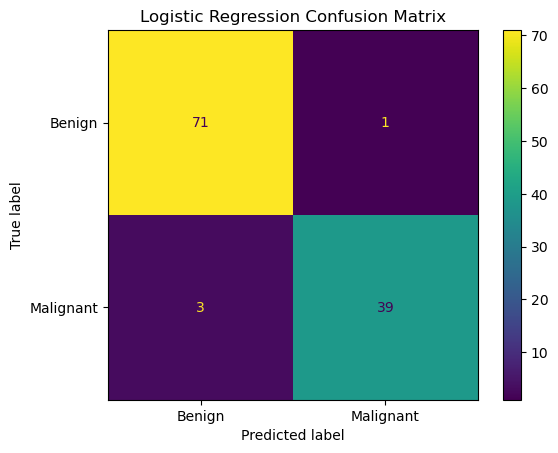

In [39]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=["Benign", "Malignant"]
)

disp.plot()

plt.title("Logistic Regression Confusion Matrix")

plt.show()

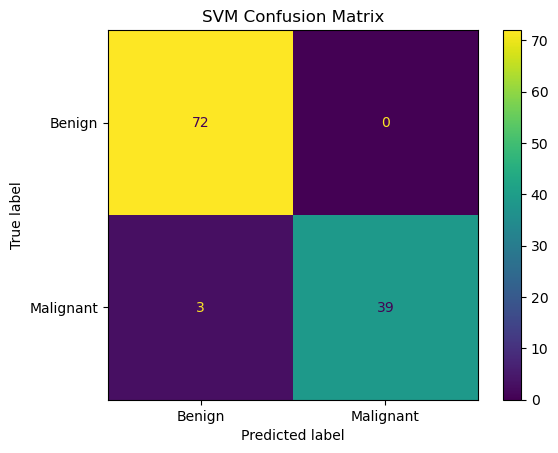

In [40]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=["Benign", "Malignant"]
)

disp.plot()

plt.title("SVM Confusion Matrix")

plt.show()

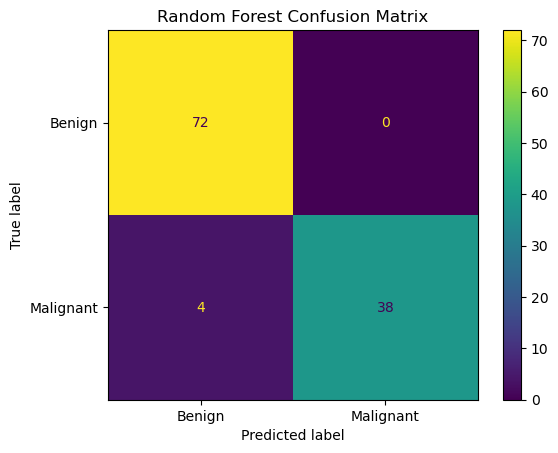

In [41]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Benign", "Malignant"]
)

disp.plot()

plt.title("Random Forest Confusion Matrix")

plt.show()

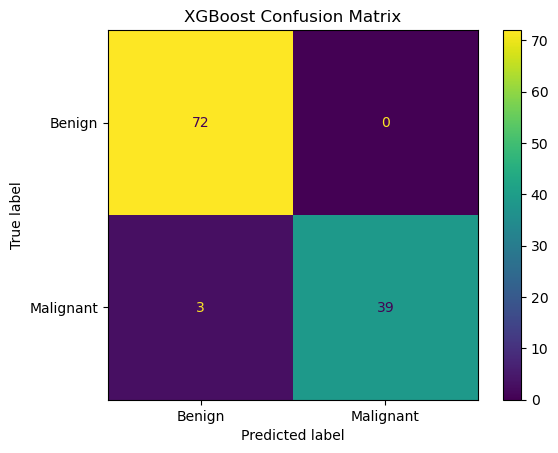

In [42]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_xgb,
    display_labels=["Benign", "Malignant"]
)

disp.plot()

plt.title("XGBoost Confusion Matrix")

plt.show()

<Figure size 900x700 with 0 Axes>

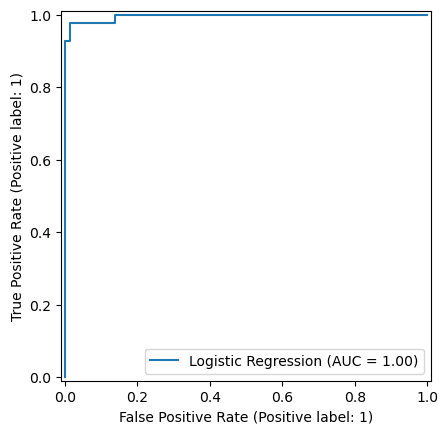

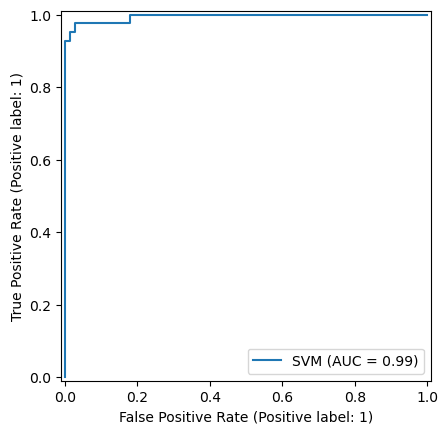

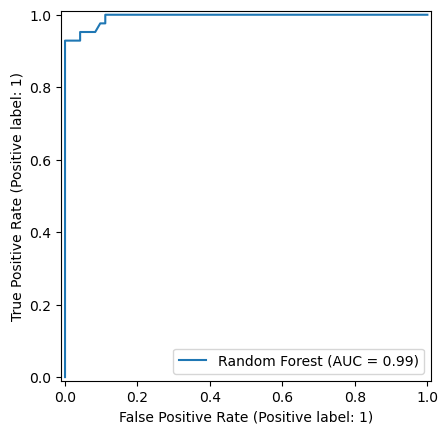

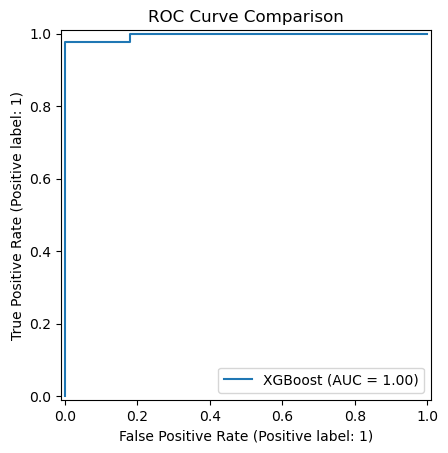

In [43]:
plt.figure(figsize=(9, 7))

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_lr,
    name="Logistic Regression"
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_svm,
    name="SVM"
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rf,
    name="Random Forest"
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_xgb,
    name="XGBoost"
)

plt.title("ROC Curve Comparison")

plt.show()

In [44]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
22,worst perimeter,0.147912
23,worst area,0.132269
27,worst concave points,0.110114
7,mean concave points,0.088200
20,worst radius,0.085116
0,mean radius,0.060554
2,mean perimeter,0.060465
3,mean area,0.044701
6,mean concavity,0.044091
26,worst concavity,0.032828


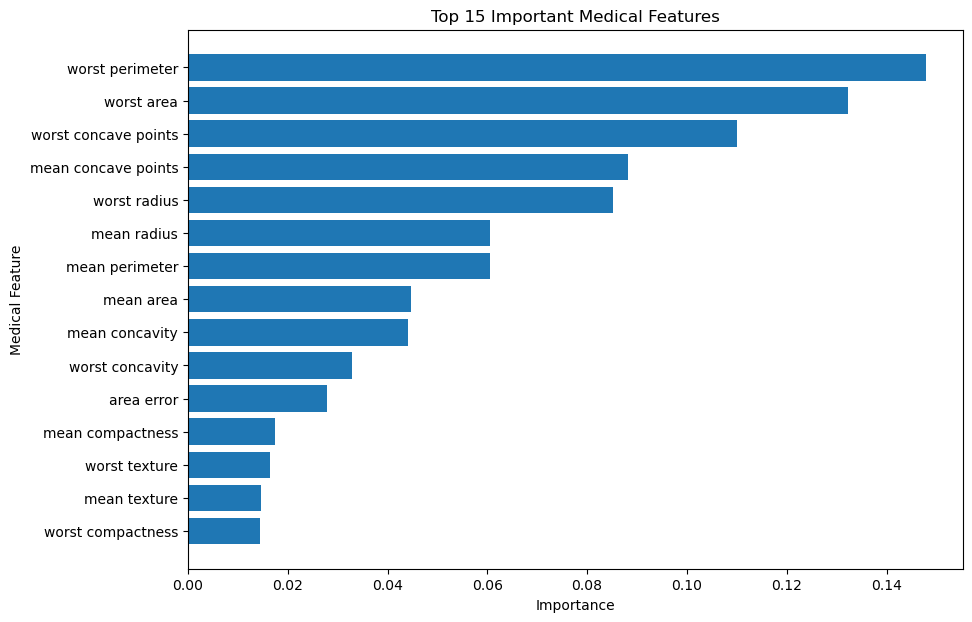

In [45]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")

plt.ylabel("Medical Feature")

plt.title("Top 15 Important Medical Features")

plt.gca().invert_yaxis()

plt.show()

In [46]:
# Take one patient from the test dataset
sample_patient = X_test.iloc[[0]]

print("Sample patient data:")
display(sample_patient)

# Scale the patient for Logistic Regression / SVM
sample_scaled = scaler.transform(sample_patient)

# Predictions
lr_prediction = logistic_model.predict(sample_scaled)[0]
svm_prediction = svm_model.predict(sample_scaled)[0]

# Random Forest and XGBoost
rf_prediction = rf_model.predict(sample_patient)[0]
xgb_prediction = xgb_model.predict(sample_patient)[0]

print("\nPredictions:")
print("Logistic Regression:", "Malignant" if lr_prediction == 1 else "Benign")
print("SVM:", "Malignant" if svm_prediction == 1 else "Benign")
print("Random Forest:", "Malignant" if rf_prediction == 1 else "Benign")
print("XGBoost:", "Malignant" if xgb_prediction == 1 else "Benign")

Sample patient data:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
120,11.41,10.82,73.34,403.3,0.09373,0.06685,0.03512,0.02623,0.1667,0.06113,...,12.82,15.97,83.74,510.5,0.1548,0.239,0.2102,0.08958,0.3016,0.08523



Predictions:
Logistic Regression: Benign
SVM: Benign
Random Forest: Benign
XGBoost: Benign


In [47]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Logistic Regression": y_pred_lr,
    "SVM": y_pred_svm,
    "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xgb
})

comparison.head(20)

,Actual,Logistic Regression,SVM,Random Forest,XGBoost
0,0,0,0,0,0
1,1,1,1,1,1
2,0,0,0,0,0
3,1,1,0,1,1
4,0,1,0,0,0
5,0,0,0,0,0
6,1,1,1,1,1
7,0,0,0,0,0
8,0,0,0,0,0
9,0,0,0,0,0


In [48]:
label_mapping = {
    0: "Benign",
    1: "Malignant"
}

comparison_labels = comparison.replace(label_mapping)

comparison_labels.head(20)

,Actual,Logistic Regression,SVM,Random Forest,XGBoost
0,Benign,Benign,Benign,Benign,Benign
1,Malignant,Malignant,Malignant,Malignant,Malignant
2,Benign,Benign,Benign,Benign,Benign
3,Malignant,Malignant,Benign,Malignant,Malignant
4,Benign,Malignant,Benign,Benign,Benign
5,Benign,Benign,Benign,Benign,Benign
6,Malignant,Malignant,Malignant,Malignant,Malignant
7,Benign,Benign,Benign,Benign,Benign
8,Benign,Benign,Benign,Benign,Benign
9,Benign,Benign,Benign,Benign,Benign


In [49]:
print("========== LOGISTIC REGRESSION ==========")

print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=["Benign", "Malignant"]
    )
)

print("========== SVM ==========")

print(
    classification_report(
        y_test,
        y_pred_svm,
        target_names=["Benign", "Malignant"]
    )
)

print("========== RANDOM FOREST ==========")

print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=["Benign", "Malignant"]
    )
)

print("========== XGBOOST ==========")

print(
    classification_report(
        y_test,
        y_pred_xgb,
        target_names=["Benign", "Malignant"]
    )
)

========== LOGISTIC REGRESSION ==========
              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

========== SVM ==========
              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114

========== RANDOM FOREST ==========
              precision    recall  f1-score   support

      Benign       0.95      1.00      0.97        72
   Malignant       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97 

In [50]:
best_model = results.loc[
    results["ROC-AUC"].idxmax(),
    "Model"
]

best_auc = results["ROC-AUC"].max()

print("Model with the highest ROC-AUC:", best_model)
print("ROC-AUC:", round(best_auc, 4))

Model with the highest ROC-AUC: Logistic Regression
ROC-AUC: 0.996


# Conclusion

In this project, machine learning techniques were applied to medical diagnostic data
to classify breast tumors as benign or malignant.

The Breast Cancer Wisconsin Diagnostic dataset was used for the experiment.
The dataset contains medical measurements derived from digitized images of breast
mass samples.

The following machine learning algorithms were implemented:

1. Logistic Regression
2. Support Vector Machine (SVM)
3. Random Forest
4. XGBoost

The dataset was first explored and checked for missing values and duplicate records.
The data was then divided into training and testing sets. Standardization was
performed for models that are sensitive to feature scale.

The models were evaluated using:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC
- Confusion Matrix
- ROC Curve

The results demonstrate how machine learning classification algorithms can be
applied to medical datasets to identify patterns associated with disease outcomes.

The model results should be interpreted as an educational machine-learning
experiment and not as a substitute for professional medical diagnosis.

In [52]:
print("=" * 60)
print("FINAL MODEL RESULTS")
print("=" * 60)

display(results_rounded)

print("\nHighest ROC-AUC model:")
print(best_model)

print("\nHighest ROC-AUC score:")
print(round(best_auc, 4))

FINAL MODEL RESULTS


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.9649,0.975,0.9286,0.9512,0.9960
1,SVM,0.9737,1.000,0.9286,0.9630,0.9947
2,Random Forest,0.9649,1.000,0.9048,0.9500,0.9942
3,XGBoost,0.9737,1.000,0.9286,0.9630,0.9957



Highest ROC-AUC model:
Logistic Regression

Highest ROC-AUC score:
0.996


In [53]:
import joblib

joblib.dump(logistic_model, "logistic_regression_model.pkl")
joblib.dump(svm_model, "svm_model.pkl")
joblib.dump(rf_model, "random_forest_model.pkl")
joblib.dump(xgb_model, "xgboost_model.pkl")

print("All trained models saved successfully.")

All trained models saved successfully.
